In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.image as mpimg
import seaborn as sns

import sklearn

In [2]:
# Read the CSV file into a pandas DataFrame
file_path = 'data/Excel/third_round/enrichment_score_with_amino_acid_sequence_threshold.xlsx'
df = pd.read_excel(file_path)
# Show the first couple of rows of the relevant columns
display(df)

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score
0,LNHHFYYV,[0.1494201476168534],1,0.149420
1,FTHHSYAG,[0.2124630124952891],1,0.212463
2,AWHHYYYI,[0.2232907823937248],1,0.223291
3,LGLFSFIP,[0.2278196077861901],1,0.227820
4,WVHHSYAN,[0.2278196077861901],1,0.227820
...,...,...,...,...
2019,GHPTNCND,[6.279767322970565],1,6.279767
2020,ACNNSSSS,[7.666316862184551],1,7.666317
2021,SCATKSTA,[7.910662076149551],1,7.910662
2022,SCTKNTSP,[8.80318330599458],1,8.803183


In [3]:
# Create a new column with the log2 of the averaged_enrichment_score
df['log2_averaged_enrichment_score'] = np.log2(df['averaged_enrichment_score'])

display(df)

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score,log2_averaged_enrichment_score
0,LNHHFYYV,[0.1494201476168534],1,0.149420,-2.742553
1,FTHHSYAG,[0.2124630124952891],1,0.212463,-2.234716
2,AWHHYYYI,[0.2232907823937248],1,0.223291,-2.163004
3,LGLFSFIP,[0.2278196077861901],1,0.227820,-2.134036
4,WVHHSYAN,[0.2278196077861901],1,0.227820,-2.134036
...,...,...,...,...,...
2019,GHPTNCND,[6.279767322970565],1,6.279767,2.650711
2020,ACNNSSSS,[7.666316862184551],1,7.666317,2.938534
2021,SCATKSTA,[7.910662076149551],1,7.910662,2.983798
2022,SCTKNTSP,[8.80318330599458],1,8.803183,3.138025


OneHot Encoding

In [4]:
def AA_hotencoding(variant):

    """
    AA_hotencoding takes an amino acid sequence 'variant' of an arbitrary length,

    and returns a 20xlength one-hot encoding matrix 'onehot_encoded'.

    """

    AAs = 'ARNDCQEGHILKMFPSTWYV'
    encoding_length = len(AAs)
    variant_length = len(variant)


    # Define a mapping of chars to integers
    char_to_int = dict((c, i) for i, c in enumerate(AAs))
    int_to_char = dict((i, c) for i, c in enumerate(AAs))


    # Encode input data
    integer_encoded = [char_to_int[char] for i, char in enumerate(variant) if i <variant_length]

    # Start one-hot-encoding
    onehot_encoded = list()

    for value in integer_encoded:
        letter = [0 for _ in range(encoding_length)]
        letter[value] = 1
        onehot_encoded.append(letter)

    return onehot_encoded

In [5]:
# Example usage
example_sequence = "SIHHKYSS"
encoded_sequence = AA_hotencoding(example_sequence)

print("Example Sequence:", example_sequence)
print("One-Hot Encoded Sequence:")
for row in encoded_sequence:
    print(row)

Example Sequence: SIHHKYSS
One-Hot Encoded Sequence:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [6]:
# apply one-hot encoding to the 'amino_acid_sequence' column

# Step 1: Apply the AA_hotencoding function to the 'amino_acid_sequence' column
df['AA_hotencoding'] = df['amino_acid_sequence'].apply(AA_hotencoding)
display(df)

print(df.shape)

,amino_acid_sequence,enrichment_score,num_replicates,averaged_enrichment_score,log2_averaged_enrichment_score,AA_hotencoding
0,LNHHFYYV,[0.1494201476168534],1,0.149420,-2.742553,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,..."
1,FTHHSYAG,[0.2124630124952891],1,0.212463,-2.234716,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,..."
2,AWHHYYYI,[0.2232907823937248],1,0.223291,-2.163004,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,LGLFSFIP,[0.2278196077861901],1,0.227820,-2.134036,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,..."
4,WVHHSYAN,[0.2278196077861901],1,0.227820,-2.134036,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...,...
2019,GHPTNCND,[6.279767322970565],1,6.279767,2.650711,"[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,..."
2020,ACNNSSSS,[7.666316862184551],1,7.666317,2.938534,"[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2021,SCATKSTA,[7.910662076149551],1,7.910662,2.983798,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2022,SCTKNTSP,[8.80318330599458],1,8.803183,3.138025,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


(2024, 6)


## Sequence-Similarity-Aware Train/Test Split

All variants are fixed-length 8-mers, so pairwise sequence identity can be computed directly as a Hamming-based match fraction using the one-hot encodings built above. A plain random split (as used in a standard train/test workflow) can place near-duplicate sequences on both sides of the split, which leaks information from train into test and inflates the reported Pearson r.

Instead, sequences are first grouped into clusters of near-duplicates (>=87.5% pairwise identity, i.e. at most 1 mismatch out of 8 positions), using connected components over a sequence-identity graph. Whole clusters are then assigned to train or test, so that no two near-identical sequences ever end up split across the two sets.

In [7]:
# Pairwise sequence identity across the *full* dataset (needed to build clusters
# before splitting). Binary one-hot matrices: their dot product counts, for every
# pair of sequences, the number of positions with an identical amino acid (each
# position contributes exactly one active dimension, so a match at that position
# is the only way the product is 1).
seq_len = df['amino_acid_sequence'].str.len().iloc[0]

full_bin = np.asarray([np.asarray(v).flatten() for v in df['AA_hotencoding'].values]).astype(int)

matches_full = full_bin @ full_bin.T
identity_full = matches_full / seq_len * 100

print(f"Sequence length: {seq_len} aa")
print(f"Full identity matrix shape: {identity_full.shape}")

Sequence length: 8 aa
Full identity matrix shape: (2024, 2024)


In [8]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# Cluster sequences into near-duplicate groups: connect two sequences whenever
# their identity is >= SIMILARITY_THRESHOLD, then take connected components as
# clusters. A cluster is the unit that is kept together on one side of the split.
SIMILARITY_THRESHOLD = 87.5  # % identity == <=1 mismatch out of 8 positions

adjacency = identity_full >= SIMILARITY_THRESHOLD
np.fill_diagonal(adjacency, False)

n_clusters, labels = connected_components(csr_matrix(adjacency), directed=False)
df['cluster'] = labels

cluster_sizes = df.groupby('cluster').size().sort_values(ascending=False)

print(f"{n_clusters} clusters found among {len(df)} sequences "
      f"(similarity threshold: {SIMILARITY_THRESHOLD}% identity, i.e. <=1 mismatch/8 aa)")
print(f"Largest cluster size: {cluster_sizes.max()}")
print(f"Sequences in clusters of size > 1: {(df.groupby('cluster')['cluster'].transform('size') > 1).sum()}")
print(cluster_sizes.describe())

1906 clusters found among 2024 sequences (similarity threshold: 87.5% identity, i.e. <=1 mismatch/8 aa)
Largest cluster size: 28
Sequences in clusters of size > 1: 183
count    1906.000000
mean        1.061910
std         0.685315
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        28.000000
dtype: float64


In [9]:
# Assign whole clusters to train or test (never split a cluster across sets).
# Clusters are visited in random order and greedily accumulated into the test
# set until the running size reaches the ~20% target -- this keeps the same
# "random 80/20 split" spirit as a plain random split, while guaranteeing that
# no two sequences within the similarity threshold end up on opposite sides.
train_size = 1620  # same target size as a plain random split, for comparability
target_test_size = len(df) - train_size

shuffled_cluster_sizes = cluster_sizes.sample(frac=1, random_state=42)
cum_size = shuffled_cluster_sizes.cumsum()
test_clusters = shuffled_cluster_sizes.index[cum_size <= target_test_size]

test_mask = df['cluster'].isin(test_clusters)
train_set = df.loc[~test_mask].drop(columns=['cluster'])
test_set = df.loc[test_mask].drop(columns=['cluster'])

print(f"Train: {len(train_set)} sequences ({len(train_set) / len(df) * 100:.1f}%)")
print(f"Test:  {len(test_set)} sequences ({len(test_set) / len(df) * 100:.1f}%)")
print(test_set)

Train: 1620 sequences (80.0%)
Test:  404 sequences (20.0%)
     amino_acid_sequence      enrichment_score  num_replicates  \
2               AWHHYYYI  [0.2232907823937248]               1   
12              TRHHLYYV   [0.272910956258997]               1   
15              WNIPRSFL   [0.276556619920696]               1   
17              CLHHNYIR  [0.2791847713454107]               1   
24              RVLVAPYF  [0.2880127483049494]               1   
...                  ...                   ...             ...   
1983            RTPDCGYD   [3.715212065436332]               1   
1995            NQAACVVS   [4.291795601501923]               1   
2001            QGGAATCS   [4.549628280728801]               1   
2002            NRDPTTCS   [4.683843684555239]               1   
2019            GHPTNCND   [6.279767322970565]               1   

      averaged_enrichment_score  log2_averaged_enrichment_score  \
2                      0.223291                       -2.163004   
12            

In [10]:
# Convert the one-hot encoded lists to numpy arrays and stack them into feature matrices
# this is necessary for the sckit-learn library to work with the data

x_train = np.asarray([np.asarray(value).flatten() for value in train_set["AA_hotencoding"].values])
y_train = train_set['log2_averaged_enrichment_score'].values


x_test = np.asarray([np.asarray(value).flatten() for value in test_set["AA_hotencoding"].values])
y_test = test_set['log2_averaged_enrichment_score'].values

Train a Linear Regression Model

In [11]:
# GOAL: Train a Linear Regression model to predict the log2_averaged_enrichment_score from the one-hot encoded amino acid sequences

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import pearsonr


# Initialize the Linear Regression model
lin_reg = LinearRegression()

# 5-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

pearsons = []

for train_idx, _ in kf.split(x_train):

    x_train_fold, y_train_fold = x_train[train_idx], y_train[train_idx]

    # Fit the model on the training data
    lin_reg.fit(x_train_fold, y_train_fold)

    # Apply the model to the one-hot encoded test set
    y_pred = lin_reg.predict(x_test)

    # Calculate Pearson Correlation Coefficient
    pearson_corr, _ = pearsonr(y_test, y_pred)
    pearsons.append(pearson_corr)

print(pearsons)
    

[0.6198386665691966, 0.5952695820375044, 0.6275277362573908, 0.5977510433747064, 0.6165666836333435, 0.6135747904704253, 0.635680912211713, 0.6179417467207449, 0.639183357849805, 0.6261261435849228]


## Sequence Similarity Between Train and Test Sets (Post-Split Check)

Same Hamming-based identity analysis as before, now used to confirm that the similarity-aware split above actually removed the near-duplicate leakage between train and test: the test-vs-train nearest-neighbour identity distribution should sit much closer to (or below) the train-vs-train baseline than it would under a plain random split.

In [12]:
train_bin = x_train.astype(int)
test_bin = x_test.astype(int)

matches_train_test = train_bin @ test_bin.T            # (n_train, n_test)
identity_train_test = matches_train_test / seq_len * 100

matches_train_train = train_bin @ train_bin.T          # (n_train, n_train)
np.fill_diagonal(matches_train_train, -1)              # exclude self-matches
identity_train_train = matches_train_train / seq_len * 100

# For every test sequence: % identity to its closest match in the training set
nn_identity_test_to_train = identity_train_test.max(axis=0)

# Reference ("null") distribution: for every training sequence, % identity to its
# closest neighbour elsewhere in the training set (same-pool baseline)
nn_identity_train_to_train = identity_train_train.max(axis=0)

print(f"Sequence length: {seq_len} aa")
print(f"Test seqs with a >={SIMILARITY_THRESHOLD}% identical (<=1 mismatch) training neighbour: "
      f"{(nn_identity_test_to_train >= SIMILARITY_THRESHOLD).sum()} / {len(nn_identity_test_to_train)}")
print(f"Median NN identity -- test vs. train:  {np.median(nn_identity_test_to_train):.1f}%")
print(f"Median NN identity -- train vs. train: {np.median(nn_identity_train_to_train):.1f}%")

Sequence length: 8 aa
Test seqs with a >=87.5% identical (<=1 mismatch) training neighbour: 0 / 404
Median NN identity -- test vs. train:  62.5%
Median NN identity -- train vs. train: 75.0%


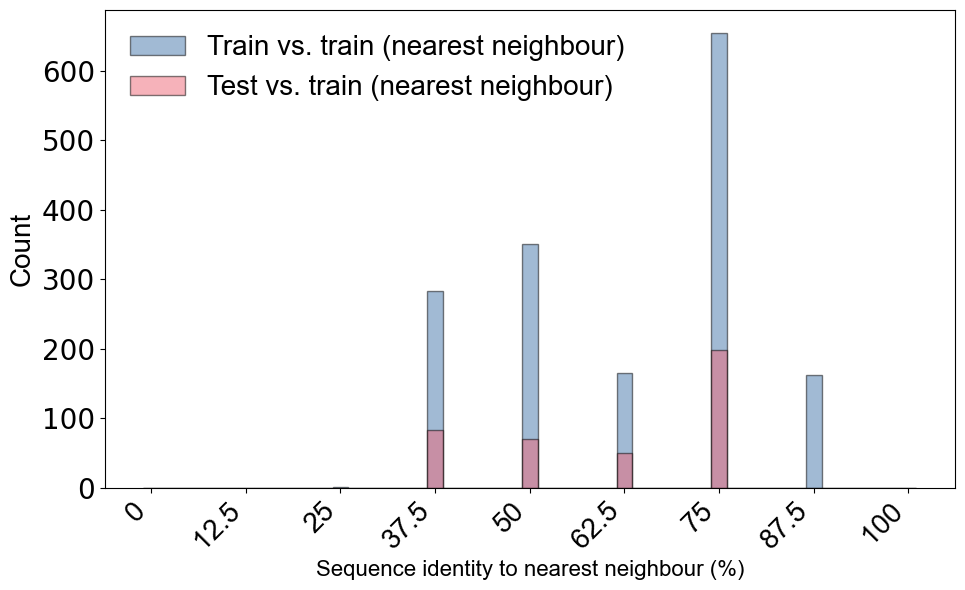

In [ ]:
# Histogram: nearest-neighbour sequence identity, test-vs-train against the
# train-vs-train baseline (consistent with the Paul Tol palette used above)
fig, ax = plt.subplots(figsize=(9.75, 6))

levels = np.linspace(0, 100, seq_len + 1)
bin_width = (100 / seq_len) / 6
bins = np.sort(np.concatenate([levels - bin_width / 2, levels + bin_width / 2]))

ax.hist(
    nn_identity_train_to_train,
    bins=bins,
    alpha=0.5,
    label='Train vs. train (nearest neighbour)',
    color='#4477AA',
    edgecolor='black'
)

ax.hist(
    nn_identity_test_to_train,
    bins=bins,
    alpha=0.5,
    label='Test vs. train (nearest neighbour)',
    color='#EE6677',
    edgecolor='black'
)

ax.set_xticks(levels)
ax.set_xticklabels([f'{b:g}' for b in levels], rotation=45, ha='right', fontsize=20, fontname='Arial')

ax.set_xlabel('Sequence identity to nearest neighbour (%)', fontsize=16, fontname='Arial')
ax.set_ylabel('Count', fontsize=20, fontname='Arial')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=20, prop={'family': 'Arial', 'size': 20}, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig("plots/supplementary_figure_S4a.png")
plt.show()

## 10-Fold CV Pearson Correlation vs. Sequence-Identity Cutoff

Sweeps the similarity-aware split above over five clustering thresholds, each corresponding to an exact mismatch count out of the 8 positions: 87.5% (<=1 mismatch), 75% (<=2 mismatches), 62.5% (<=3 mismatches), 50% (<=4 mismatches), and 37.5% (<=5 mismatches). For each cutoff, the model is retrained on 10 random subsamples of the resulting train set and evaluated on the one fixed test set for that cutoff (same procedure as the single-threshold cells above), and the mean Pearson r across those 10 fits is reported.

In [15]:
def cluster_labels_at_threshold(bin_matrix, seq_len, threshold_pct):
    """Connected components over the sequence-identity graph at a given % identity threshold."""
    matches = bin_matrix @ bin_matrix.T
    identity = matches / seq_len * 100
    adjacency = identity >= threshold_pct
    np.fill_diagonal(adjacency, False)
    _, labels = connected_components(csr_matrix(adjacency), directed=False)
    return labels


def split_at_cutoff(df_in, bin_matrix, seq_len, threshold_pct, test_frac=0.2, seed=42):
    """Similarity-aware train/test split at a given cutoff; `None` = plain random split.

    Returns (train_idx, test_idx), or (None, None) if no combination of whole
    clusters can fill the test set -- this happens once a single cluster spans
    too large a fraction of the dataset to leave room for the ~test_frac target.
    """
    if threshold_pct is None:
        rng = np.random.RandomState(seed)
        idx = rng.permutation(len(df_in))
        n_test = int(round(len(df_in) * test_frac))
        return idx[n_test:], idx[:n_test]

    labels = cluster_labels_at_threshold(bin_matrix, seq_len, threshold_pct)
    sizes = pd.Series(labels).value_counts().sample(frac=1, random_state=seed)
    cum = sizes.cumsum()
    test_clusters = sizes.index[cum <= len(df_in) * test_frac]
    if len(test_clusters) == 0:
        return None, None
    test_mask = np.isin(labels, test_clusters)
    return np.where(~test_mask)[0], np.where(test_mask)[0]


def cv_pearson_sweep(df_in, seq_col, label_col, thresholds, n_folds=10, seed=42):
    """Mean 10-fold CV test Pearson r at each identity cutoff in `thresholds`.

    A cutoff for which no valid split exists (see split_at_cutoff) yields NaN.
    """
    seqs = df_in[seq_col].tolist()
    s_len = len(seqs[0])
    bin_matrix = np.asarray([np.asarray(AA_hotencoding(s)).flatten() for s in seqs]).astype(int)
    y_full = df_in[label_col].values

    means = []
    for t in thresholds:
        train_idx, test_idx = split_at_cutoff(df_in, bin_matrix, s_len, t, seed=seed)
        if train_idx is None:
            print(f"  cutoff={t}: no valid split (a single cluster spans too much "
                  f"of the dataset at this threshold) -- skipping")
            means.append(np.nan)
            continue

        xt, yt = bin_matrix[train_idx], y_full[train_idx]
        xv, yv = bin_matrix[test_idx], y_full[test_idx]

        kf_sweep = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
        fold_pearsons = []
        for fold_train_idx, _ in kf_sweep.split(xt):
            model = LinearRegression().fit(xt[fold_train_idx], yt[fold_train_idx])
            r, _ = pearsonr(yv, model.predict(xv))
            fold_pearsons.append(r)
        means.append(np.mean(fold_pearsons))
    return means


# Thresholds expressed as % identity, each corresponding to an exact mismatch
# count out of the 8 aa positions.
THRESHOLDS = [87.5, 75, 62.5, 50]
THRESHOLD_LABELS = ['87.5%', '75%', '62.5%','50%']

df_cutoff = pd.read_excel(file_path)
df_cutoff['log2_averaged_enrichment_score'] = np.log2(df_cutoff['averaged_enrichment_score'])
pearsons_by_cutoff = cv_pearson_sweep(df_cutoff, 'amino_acid_sequence', 'log2_averaged_enrichment_score', THRESHOLDS)

for label, r in zip(THRESHOLD_LABELS, pearsons_by_cutoff):
    print(f"cutoff={label.splitlines()[0]:>6}  r={r:.3f}" if not np.isnan(r) else f"cutoff={label.splitlines()[0]:>6}  r=NaN")

cutoff= 87.5%  r=0.619
cutoff=   75%  r=0.661
cutoff= 62.5%  r=0.521
cutoff=   50%  r=0.585


/tmp/ipykernel_6067/2068621637.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1.0], fontsize=20, fontname='Arial')


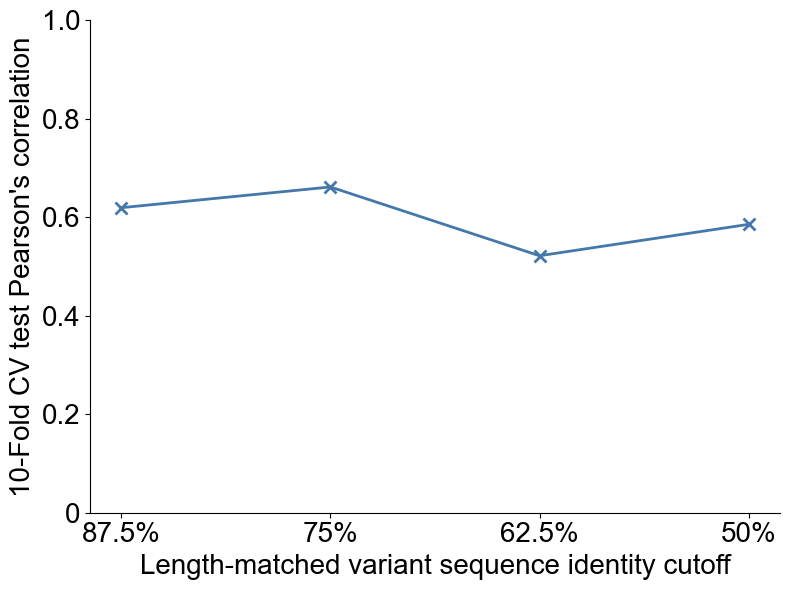

In [ ]:
# Line plot: 10-fold CV test Pearson r vs. sequence-identity cutoff
# (consistent with the Paul Tol palette used elsewhere in this notebook)
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(THRESHOLDS))

ax.plot(x, pearsons_by_cutoff, marker='x', markersize=9, markeredgewidth=2,
        linewidth=2, color='#4477AA')

ax.set_xticks(x)
ax.set_xticklabels(THRESHOLD_LABELS, fontsize=20, fontname='Arial')
ax.set_xlabel('Length-matched variant sequence identity cutoff', fontsize=20, fontname='Arial')
ax.set_ylabel("10-Fold CV test Pearson's correlation", fontsize=20, fontname='Arial')
ax.set_ylim(0, 1.0)
ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1.0], fontsize=20, fontname='Arial')
ax.tick_params(axis='both', which='major', labelsize=20)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("plots/supplementary_figure_S4b.png")
plt.show()